# K-Nearest Neighbors (KNN) Classifier: Predicting Tree Carbon Change
This notebook builds an ML model to predict whether the tree carbon capture impact (`TPH.gs.dC.dN0.01`) is **Positive** (Gain in Carbon) or **Negative/Zero** (Loss/Neutral).

We've converted the target variable into a Binary Classification problem to utilize classification metrics (F1, Precision, Recall, Accuracy, MCC, ROC-AUC).

**Enhancements Applied**:
1. **Additional Categorical Features** for deeper geological awareness.
2. **RobustScaler** to mitigate extreme anomalies mathematically disrupting KNN mapping.
3. **GridSearchCV Hyperparameter Tuning** to algorithmically pinpoint the exact `n_neighbors` needed for highest accuracy.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             matthews_corrcoef, roc_auc_score, roc_curve, 
                             confusion_matrix, ConfusionMatrixDisplay)

# Set plotting style
sns.set_theme(style='whitegrid')


### 1. Load Data & Transform Target
Read the raw dataset. Convert the continuous target variable `TPH.gs.dC.dN0.01` into a Binary feature `Is_Positive_Carbon_Change`.


In [2]:
data_path = '../data/raw/dCdN_plot_data.csv'
df = pd.read_csv(data_path)

# Define Original Target
regression_target = 'TPH.gs.dC.dN0.01'

# Drop NaNs safely
df = df.dropna(subset=[regression_target])

# Create Categorical/Binary Classification Target
# Class 1: Positive Carbon Change (Target > 0)
# Class 0: Negative/Neutral Change (Target <= 0)
df['Is_Positive_Carbon_Change'] = (df[regression_target] > 0).astype(int)

# Check class balance
print("Target Class Distribution:")
print(df['Is_Positive_Carbon_Change'].value_counts(normalize=True) * 100)

df[['TPH.gs.dC.dN0.01', 'Is_Positive_Carbon_Change']].head()


Target Class Distribution:
Is_Positive_Carbon_Change
1    54.809761
0    45.190239
Name: proportion, dtype: float64


,TPH.gs.dC.dN0.01,Is_Positive_Carbon_Change
0,6.410834,1
1,0.000000,0
2,15.382564,1
3,2.403577,1
4,28.951024,1


### 2. Feature Selection
Adding deeper categorical features (Ecoregions, etc.) to give the classifier better groupings.


In [3]:
target_col = 'Is_Positive_Carbon_Change'

# Continuous Variables
num_features = ['LAT', 'LON', 'EXPN.ha']

# Extended Categorical Variables for better grouping
cat_features = ['STATECD', 'NA_L1CODE', 'US_L4CODE', 'NA_L3CODE', 'COUNTYCD', 'e1', 'e3', 'e4']

# Filter dataset
X = df[num_features + cat_features]
y = df[target_col]

# Train-Test Split (80/20) - Stratified is important when doing classification!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing data shape:  X={X_test.shape}, y={y_test.shape}")


Training data shape: X=(88520, 11), y=(88520,)
Testing data shape:  X=(22130, 11), y=(22130,)


### 3. Build Preprocessing & Pipeline
Switching to `RobustScaler` to ensure any unremoved geographic outliers don't break the KNN calculation. Applying `OneHotEncoder` to categoricals.


In [4]:
# Handle unknown categories safely when using OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# Pipeline
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier()) # Parameters blank currently for GridSearch below
])


### 4. Hyperparameter Tuning (GridSearch)
Instead of guessing `K=5`, we test dozens of combinations combining K (`[3, 5, 9, 15, 21]`) and Weighting (`uniform` vs `distance`) using 3-Fold Cross-Validation.

*Note: KNN distance matrices are extremely memory-intensive on 100,000+ rows. To prevent your laptop from freezing and crashing (WinError 1450), the hyperparameter search is conducted dynamically on a random 20,000 row subset. The final tuned model is then trained on the full dataset.*


In [5]:
# Parameter grid for searching
param_grid = {
    'classifier__n_neighbors': [3, 5, 9, 15, 21],  # Test these K values
    'classifier__weights': ['uniform', 'distance']
}

# Grid Search Config
# Removed n_jobs=-1 to prevent Windows Multi-processing OS limit crashes (WinError 1450)
grid_search = GridSearchCV(knn_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=1, verbose=1)

print("Starting hyperparameter tuning on a 20,000 row subsample...")
X_train_sample = X_train.sample(n=min(20000, len(X_train)), random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

grid_search.fit(X_train_sample, y_train_sample)

print(f"\nBest Parameters Discovered: {grid_search.best_params_}")
print(f"Best cross-validation accuracy on sub-sample: {grid_search.best_score_:.4f}")

# Extract best tuned model and train it on the FULL 80,000+ row training dataset
best_model = grid_search.best_estimator_
print("Training the final tuned model on the full dataset. This will take a moment...")
best_model.fit(X_train, y_train)
print("Finished!")


Starting hyperparameter tuning on a 20,000 row subsample...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters Discovered: {'classifier__n_neighbors': 21, 'classifier__weights': 'uniform'}
Best cross-validation accuracy on sub-sample: 0.6627
Training the final tuned model on the full dataset. This will take a moment...
Finished!


### 5. Evaluate Classification Metrics
Compute the exact metrics requested!


In [6]:
# Predict test set
y_pred = best_model.predict(X_test)

# Predict probabilities (needed for ROC-AUC)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate classification metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
mcc = matthews_corrcoef(y_test, y_pred)

print("----- Tuned Model Performance (Test Set) -----")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(f"MCC:       {mcc:.4f}")


----- Tuned Model Performance (Test Set) -----
Accuracy:  0.6810
Precision: 0.6969
Recall:    0.7397
F1 Score:  0.7176
ROC-AUC:   0.7482
MCC:       0.3526


### 6. Visualization: Performance Metrics, Confusion Matrix, and ROC Curve


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20264\2869683227.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_names, y=metrics_values, ax=axes[0], palette='viridis')


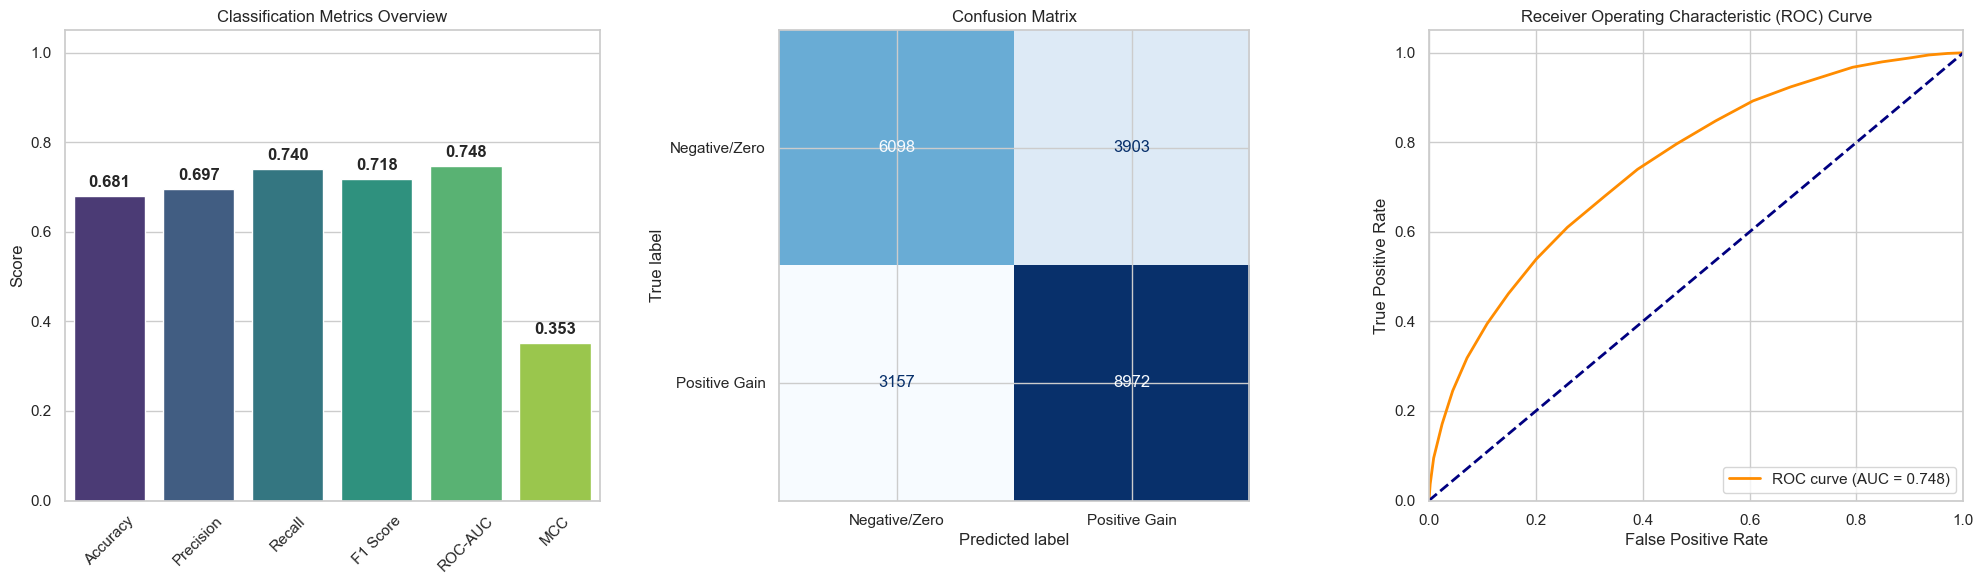

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Bar Chart of Metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'MCC']
metrics_values = [acc, prec, rec, f1, roc_auc, mcc]

sns.barplot(x=metrics_names, y=metrics_values, ax=axes[0], palette='viridis')
axes[0].set_ylim([0.0, 1.05])
axes[0].set_title('Classification Metrics Overview')
axes[0].set_ylabel('Score')
for i, v in enumerate(metrics_values):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Plot 2: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative/Zero', 'Positive Gain'])
disp.plot(ax=axes[1], cmap=plt.cm.Blues, values_format='d', colorbar=False)
axes[1].set_title('Confusion Matrix')

# Plot 3: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()
